# IMPORTS

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt

# Loading Dataset

In [ ]:

df = pd.read_csv("4) house Prediction Data Set.csv",
                 delim_whitespace=True,
                 names=["CRIME","ZONE","INDUS","RIVER","POLLUTION(NO)","ROOM","AGE","DIS_JOB","HIGHWAY","TAX","Stud_teach_RATIO","B","LSTAT","MED_HOUSE_V"],
                header=None  )


/tmp/ipykernel_1755/53369565.py:1: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df = pd.read_csv("4) house Prediction Data Set.csv",


In [ ]:
df.head()


,CRIME,ZONE,INDUS,RIVER,POLLUTION(NO),ROOM,AGE,DIS_JOB,HIGHWAY,TAX,Stud_teach_RATIO,B,LSTAT,MED_HOUSE_V
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296.0,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242.0,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242.0,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222.0,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222.0,18.7,396.90,5.33,36.2


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 506 entries, 0 to 505
Data columns (total 14 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   CRIME             506 non-null    float64
 1   ZONE              506 non-null    float64
 2   INDUS             506 non-null    float64
 3   RIVER             506 non-null    int64  
 4   POLLUTION(NO)     506 non-null    float64
 5   ROOM              506 non-null    float64
 6   AGE               506 non-null    float64
 7   DIS_JOB           506 non-null    float64
 8   HIGHWAY           506 non-null    int64  
 9   TAX               506 non-null    float64
 10  Stud_teach_RATIO  506 non-null    float64
 11  B                 506 non-null    float64
 12  LSTAT             506 non-null    float64
 13  MED_HOUSE_V       506 non-null    float64
dtypes: float64(12), int64(2)
memory usage: 55.5 KB


In [ ]:
df.isnull().sum()

,0
CRIME,0
ZONE,0
INDUS,0
RIVER,0
POLLUTION(NO),0
ROOM,0
AGE,0
DIS_JOB,0
HIGHWAY,0
TAX,0


# Simple Linear Regression

In [ ]:
X = df[["LSTAT"]]   #dataframe(2D) Models need 2D input (X)
y = df["MED_HOUSE_V"]  #series


In [ ]:

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)


In [ ]:

model = LinearRegression()
model.fit(X_train, y_train)


LinearRegression()

In [ ]:

print("Coefficient (slope):", model.coef_[0])
print("Intercept:", model.intercept_)


Coefficient (slope): -0.966530901950353
Intercept: 34.83694982031851


MEDV=−0.9665×LSTAT+34.8369

*   When the percentage of lower-income population increases, house prices decrease.
*   If there were no lower-income population, the predicted house price would be about 34.84



In [ ]:
y_pred = model.predict(X_test)

In [ ]:
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("MSE:", mse)
print("R²:", r2)



MSE: 33.51954917268489
R²: 0.5429180422970384




*   MSE (33.52): The model makes a noticeable amount of error when predicting house prices.

*   R² (0.54): The model explains about half of the variation in house prices.



In [ ]:
comparison = pd.DataFrame({
    "Actual": y_test,
    "Predicted": y_pred
})

print(comparison.head())

     Actual  Predicted
173    23.6  26.099510
274    32.4  31.425096
491    13.6  17.371736
72     22.8  29.501699
452    16.1  18.144961


### Visualize

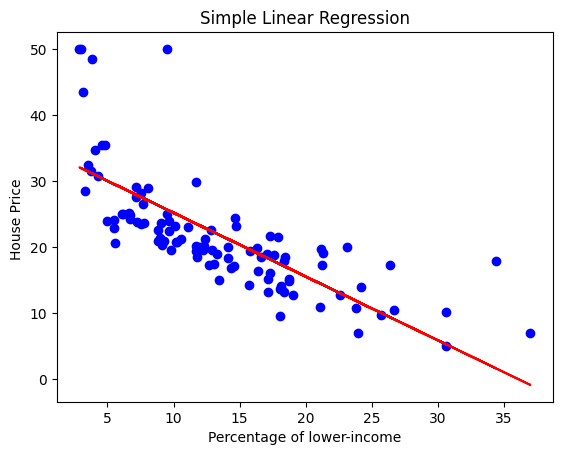

In [ ]:
plt.scatter(X_test, y_test, color='blue')

plt.plot(X_test, y_pred, color='red')

plt.xlabel("Percentage of lower-income")
plt.ylabel("House Price ")
plt.title("Simple Linear Regression")

plt.show()


### Observation:
The plot shows a clear negative relationship between LSTAT and house prices. As the percentage of lower-income population increases, the house price decreases. The data points follow a downward trend, and the regression line fits this pattern well. However, some points are scattered around the line, indicating prediction errors. Overall, LSTAT is an important factor influencing house prices but does not fully explain all variations.

# Regression With Multiple Feature

To improve the model, the most relevant features such as ROOM, LSTAT, Stud_teach_RATIO,and POLLUTION(NO) were selected. These features have a strong relationship with house prices, which helps the model make more accurate predictions. Removing less important features reduces noise and improves the model’s performance.

In [ ]:
X = df[["ROOM", "LSTAT", "Stud_teach_RATIO","POLLUTION(NO)"]]
y = df["MED_HOUSE_V"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

In [ ]:
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(404, 4)
(102, 4)
(404,)
(102,)


In [ ]:
model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

In [ ]:

print("Intercept:", model.intercept_)
print("Coefficients:", model.coef_)


Intercept: 15.197795770392972
Coefficients: [ 4.95890701 -0.54873009 -0.87125627 -1.66313049]


In [ ]:
y_pred = model.predict(X_test)

In [ ]:

mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("Mean Squared Error:", mse)
print("R-squared:", r2)


Mean Squared Error: 26.978805082769387
R-squared: 0.6321094600589733


The Mean Squared Error (MSE) is 26.98, which indicates a relatively lower prediction error. The R² value of 0.63 shows that the model explains about 63% of the variation in house prices. This suggests that the model performs well and provides reasonably accurate predictions.

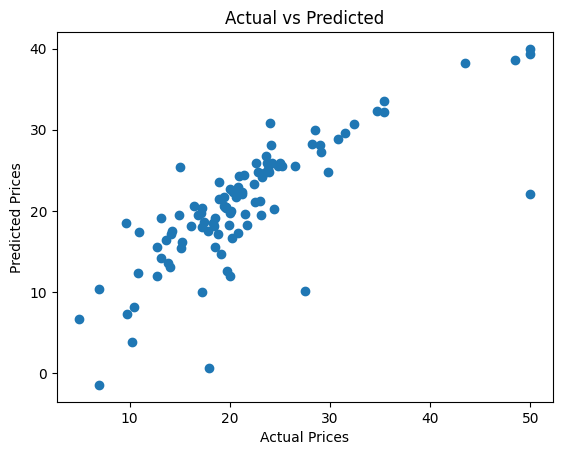

In [ ]:

plt.scatter(y_test, y_pred)
plt.xlabel("Actual Prices")
plt.ylabel("Predicted Prices")
plt.title("Actual vs Predicted")
plt.show()


**Simple Linear Regression vs Regression With Multiple Feature:**

The improved model performs better
than the simple model. It has a lower MSE (26.98 vs 33.52), meaning fewer prediction errors, and a higher R² (0.63 vs 0.54), indicating it explains more variation in house prices. This shows that using multiple important features improves the model’s accuracy compared to using a single feature.

*  Overall, adding more relevant features improves prediction performance and reduces error.


